In [8]:
import pandas as pd

# Chargement de la base de données
df = pd.read_excel(r"C:\Users\HP-PC\Downloads\BDD_CAPM_nettoyee.xlsx")

# Vérification
print("Dimensions :", df.shape)
print("\nAperçu des premières lignes :")
df.head()

Dimensions : (22188, 12)

Aperçu des premières lignes :


,Age Année,Sexe,Milieu,Région,Circonstance,Sous circonstance,type de produit1,Produit 1,Voie 1,Symptomatologie,Gradation finale,Tranche_age
0,25.0,Féminin,Urbain,Rabat-Salé-Kénitra,Inconnu,Inconnu,Médicament,SEROQUEL,Orale,Oui,Grade 2,16-30 ans
1,20.0,Féminin,Urbain,Casablanca-Settat,Inconnu,Inconnu,Médicament,LAROXYL,Orale,Oui,Grade 2,16-30 ans
2,16.0,Féminin,Urbain,Fès-Meknès,Accidentelle,Accident classique,Médicament,FLUOXETINE,Orale,Oui,Grade 2,16-30 ans
3,2.0,Masculin,Urbain,Fès-Meknès,Accidentelle,Erreur thérapeutique,Médicament,CODETUX,Orale,Oui,Grade 0,0-5 ans
4,32.0,Masculin,Inconnu,Casablanca-Settat,Accidentelle,Effet indésirable,Médicament,MEDICAMENT INCONNU,Inconnu,Oui,Grade 2,31-60 ans


In [9]:
compte_produits = df['Produit 1'].value_counts()

# Trié du plus fréquent au moins fréquent, pour prioriser ta relecture
compte_produits.to_excel("liste_complete_produits.xlsx", header=['nombre_occurrences'])
print(f"{len(compte_produits)} produits exportés dans liste_complete_produits.xlsx")

5960 produits exportés dans liste_complete_produits.xlsx


In [10]:
import os
print("Dossier courant :", os.getcwd())
print("Chemin complet du fichier :", os.path.join(os.getcwd(), "liste_complete_produits.xlsx"))

Dossier courant : C:\Users\HP-PC
Chemin complet du fichier : C:\Users\HP-PC\liste_complete_produits.xlsx


In [11]:
import re
import unicodedata

def retirer_accents(val):
    """Transforme É, è, ô, etc. en E, e, o, etc."""
    return ''.join(c for c in unicodedata.normalize('NFD', val)
                   if unicodedata.category(c) != 'Mn')

def nettoyer_produit(val):
    val = str(val).strip().upper()           # supprime espaces début/fin, met en majuscules
    val = re.sub(r'\s+', ' ', val)            # remplace espaces multiples par un seul espace
    val = retirer_accents(val)                # supprime les accents
    return val

# ─── Avant nettoyage ───
print("Nombre de valeurs uniques AVANT nettoyage :", df['Produit 1'].nunique())

# ─── Application du nettoyage ───
df['Produit 1'] = df['Produit 1'].apply(nettoyer_produit)

# ─── Après nettoyage ───
print("Nombre de valeurs uniques APRÈS nettoyage :", df['Produit 1'].nunique())

Nombre de valeurs uniques AVANT nettoyage : 5960
Nombre de valeurs uniques APRÈS nettoyage : 4861


In [12]:
compte_apres = df['Produit 1'].value_counts()
compte_apres.to_excel("liste_produits_apres_nettoyage.xlsx", header=['nombre_occurrences'])
print(f"{len(compte_apres)} produits restants exportés dans liste_produits_apres_nettoyage.xlsx")

4861 produits restants exportés dans liste_produits_apres_nettoyage.xlsx


In [13]:
compte_apres = df['Produit 1'].value_counts()
compte_apres.to_excel("liste_produits_apres_nettoyage.xlsx", header=['nombre_occurrences'])
print(f"{len(compte_apres)} produits restants exportés dans liste_produits_apres_nettoyage.xlsx")

4861 produits restants exportés dans liste_produits_apres_nettoyage.xlsx


In [14]:
import os
print("Dossier courant :", os.getcwd())
print("Chemin complet du fichier :", os.path.join(os.getcwd(), "liste_produits_apres_nettoyage.xlsx"))

Dossier courant : C:\Users\HP-PC
Chemin complet du fichier : C:\Users\HP-PC\liste_produits_apres_nettoyage.xlsx


In [15]:
import re
import unicodedata

def normaliser(val):
    val = str(val).strip().upper()
    val = re.sub(r'\s+', ' ', val)
    val = ''.join(c for c in unicodedata.normalize('NFD', val) if unicodedata.category(c) != 'Mn')
    return val

verif = df['Produit 1'].apply(normaliser)
nb_encore_fusionnables = df['Produit 1'].nunique() - verif.nunique()
print(f"Doublons casse/accents/espaces restants : {nb_encore_fusionnables}")
# Si ce chiffre est 0, ton nettoyage précédent a bien tout couvert

Doublons casse/accents/espaces restants : 0


In [16]:
from difflib import SequenceMatcher

# On se concentre sur les produits qui apparaissent au moins 3 fois
# (les valeurs uniques une seule fois sont trop nombreuses et finissent de toute façon dans "AUTRE")
compte = df['Produit 1'].value_counts()
produits_a_verifier = compte[compte >= 3].index.tolist()
print(f"Nombre de produits à comparer entre eux : {len(produits_a_verifier)}")

seuil_similarite = 0.85  # entre 0 et 1 ; plus proche de 1 = plus strict
paires_suspectes = []

for i in range(len(produits_a_verifier)):
    for j in range(i + 1, len(produits_a_verifier)):
        a, b = produits_a_verifier[i], produits_a_verifier[j]
        score = SequenceMatcher(None, a, b).ratio()
        if score >= seuil_similarite:
            paires_suspectes.append((a, b, round(score, 3), compte[a], compte[b]))

paires_suspectes.sort(key=lambda x: -x[2])  # les plus similaires en premier

print(f"\n{len(paires_suspectes)} paires suspectes trouvées :\n")
for a, b, score, cnt_a, cnt_b in paires_suspectes:
    print(f"'{a}' ({cnt_a}x)  <-->  '{b}' ({cnt_b}x)   similarité={score}")

Nombre de produits à comparer entre eux : 847

113 paires suspectes trouvées :

'EAU DE JAVEL CONCENTREE' (17x)  <-->  'EAU DE JAVEL CONCENTRE' (4x)   similarité=0.978
'PILULE CONTRACEPTIVE' (108x)  <-->  'PILLULE CONTRACEPTIVE' (33x)   similarité=0.976
'GEL HYDRO-ALCOOLIQUE' (25x)  <-->  'GEL HYDROALCOOLIQUE' (15x)   similarité=0.974
'MONOXYDE DE CARBONE' (67x)  <-->  'MONOXYDE DE CARBON' (7x)   similarité=0.973
'ACIDE CHLORHYDRIQUE' (11x)  <-->  'ACIDE CHLORYDRIQUE' (3x)   similarité=0.973
'MOOXYDE DE CARBON' (33x)  <-->  'MONOXYDE DE CARBON' (7x)   similarité=0.971
'DOLIPEDIATRIQUE' (32x)  <-->  'DOLI PEDIATRIQUE' (17x)   similarité=0.968
'MORSURE INCONNUE' (13x)  <-->  'MORSURE INCONNU' (7x)   similarité=0.968
'ORGANOPHOSPHORES' (9x)  <-->  'ORGANOPHOSPHORE' (4x)   similarité=0.968
'LARGACTIL 100 MG' (6x)  <-->  'LARGACTIL 100MG' (3x)   similarité=0.968
'PRODUIT GAZEUX' (694x)  <-->  'PRODUITS GAZEUX' (8x)   similarité=0.966
'ALPHACHLORALOSE' (58x)  <-->  'ALPHACLORALOSE' (16x)   s

In [17]:
synonymes = {
    # Fautes de frappe / variantes d'écriture confirmées
    'EAU DE JAVEL CONCENTRE': 'EAU DE JAVEL CONCENTREE',
    'PILLULE CONTRACEPTIVE': 'PILULE CONTRACEPTIVE',
    'GEL HYDROALCOOLIQUE': 'GEL HYDRO-ALCOOLIQUE',
    'HYDROALCOOLIQUE': 'GEL HYDRO-ALCOOLIQUE',
    'MONOXYDE DE CARBON': 'MONOXYDE DE CARBONE',
    'MOOXYDE DE CARBON': 'MONOXYDE DE CARBONE',
    'ACIDE CHLORYDRIQUE': 'ACIDE CHLORHYDRIQUE',
    'DOLI PEDIATRIQUE': 'DOLIPEDIATRIQUE',
    "DOLI PEDIATRIQUE 0,03": 'DOLIPEDIATRIQUE',
    'MORSURE INCONNU': 'MORSURE INCONNUE',
    'ORGANOPHOSPHORE': 'ORGANOPHOSPHORES',
    'LARGACTIL 100MG': 'LARGACTIL 100 MG',
    'PRODUITS GAZEUX': 'PRODUIT GAZEUX',
    'ALPHACLORALOSE': 'ALPHACHLORALOSE',
    'PIQURE INCONNU': 'PIQURE INCONNUE',
    'PIQURE INCONUU': 'PIQURE INCONNUE',
    'DOLIPRANE 1G': 'DOLIPRANE 1 G',
    'WHITE SPIRITE': 'WHITE SPIRIT',
    'SPASFON 80MG': 'SPASFON 80 MG',
    'PARACETAMOUL': 'PARACETAMOL',
    'PARACITAMOL': 'PARACETAMOL',
    'RATICIDE 70%': 'RATICIDE 70',
    'RATCIDE': 'RATICIDE',
    'RATICID': 'RATICIDE',
    'RATICIDES': 'RATICIDE',
    'NODEP 50 MG': 'NO-DEP 50 MG',
    'NODEP 50MG': 'NO-DEP 50 MG',
    'NODEP 50': 'NO-DEP 50 MG',
    'NODEP': 'NO-DEP',
    'COMPLIMENT ALIMENTAIRE': 'COMPLEMENT ALIMENTAIRE',
    'SANDWISH VIANDE HACHEE': 'SANDWICH VIANDE HACHEE',
    'SANDWISH': 'SANDWICH',
    'ANTI CAFARD': 'ANTICAFARD',
    'ANXIOL 6MG': 'ANXIOL 6 MG',
    'XCHLORALOSE': 'CHLORALOSE',
    'PESTICIDES': 'PESTICIDE',
    'IBUPROFEN': 'IBUPROFENE',
    'MEDIZAPIN': 'MEDIZAPINE',
    'CIGARETTES': 'CIGARETTE',
    'ZEPAM 6MG': 'ZEPAM 6 MG',
    'ANTI POUX': 'ANTIPOUX',
    'PRODUIT CHEMIQUE': 'PRODUIT CHIMIQUE',
    'INCONNUE': 'INCONNU',
    'INCONUE': 'INCONNU',
    'INCONUU': 'INCONNU',
    'MAAJOUN': 'MAAJOUNE',
    'CLOPRAM': 'CLOPRAME',
    'CLOPRANE': 'CLOPRAME',
    'POISSONS': 'POISSON',
    'APPETINE': 'APETINE',
    'RELAXUM': 'RELAXIUM',
    "L'EAU DE JAVEL": 'EAU DE JAVEL',
    'EAU DE JAVEL ACE': 'EAU DE JAVEL',
    'EAU JAVEL': 'EAU DE JAVEL',
    'ALCOHOL': 'ALCOOL',
    'SALADES': 'SALADE',
    'PILLULE': 'PILULE',
    'PELLULE': 'PILULE',
    'ALPRAZ 0,5 MG': 'ALPRAZ 0.5 MG',
    'ALPRAZ 0.5': 'ALPRAZ 0.5 MG',
    'BUTAINE': 'BUTANE',
    'DULIANT': 'DILUANT',
    'DILIANT': 'DILUANT',
    'NO-DEP 50 MG_DUP': 'NO-DEP 50 MG',  # garde-fou si doublon exact
    'GAZ BUTAIN': 'GAZ BUTANE',
    'PHOSPHORE ALUMINIUM': "PHOSPHURE D'ALUMINIUM",
    'RAIBI': 'RAIB',
    'HERBECIDE': 'HERBICIDE',
    'SANDWICH': 'SANDWICH',  # neutre, garde tel quel
    'YAGHOURT': 'YAOURT',
    'PROSPON': 'PROSPAN',
    'MODOPAR': 'MADOPAR',
    'CO 2': 'CO2',
    "BOISSON D'ALCOOLE": 'BOISSON ALCOOLIQUE',
    'TON': 'THON',
    'LEVOMAZINE': 'LEVOMEPROMAZINE',
    'LEVOPROMAZINE': 'LEVOMEPROMAZINE',
}

df['Produit 1'] = df['Produit 1'].replace(synonymes)
print("Nombre de valeurs uniques après fusion des synonymes :", df['Produit 1'].nunique())

Nombre de valeurs uniques après fusion des synonymes : 4786


In [18]:
seuil = 30
compte_produits = df['Produit 1'].value_counts()
produits_frequents = compte_produits[compte_produits >= seuil].index.tolist()

def regrouper_produit(val):
    return val if val in produits_frequents else 'AUTRE'

df['Produit_Regroupe'] = df['Produit 1'].apply(regrouper_produit)

print("Nombre de produits fréquents :", len(produits_frequents))
print("Nombre de catégories finales :", df['Produit_Regroupe'].nunique())

pct_autre = 100 * (df['Produit_Regroupe'] == 'AUTRE').sum() / len(df)
print(f"% de cas dans 'AUTRE' : {pct_autre:.1f}%")

Nombre de produits fréquents : 92
Nombre de catégories finales : 93
% de cas dans 'AUTRE' : 43.0%


In [22]:
df = df.drop(columns=['Symptomatologie '])
print("\nDimensions après suppression :", df.shape)

print("\nDistribution de Gradation finale :")
print(df['Gradation finale'].value_counts())


Dimensions après suppression : (22188, 12)

Distribution de Gradation finale :
Gradation finale
Grade 2    9932
Grade 0    7929
Grade 1    3567
Grade 3     605
Grade 4     155
Name: count, dtype: int64


C:\Users\HP-PC\anaconda3\envs\projet_ml\Lib\site-packages\sklearn\linear_model\_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
C:\Users\HP-PC\anaconda3\envs\projet_ml\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== Régression Logistique (baseline) ===
              precision    recall  f1-score   support

     Grade 0       0.63      0.77      0.69      1586
     Grade 1       0.44      0.31      0.37       713
     Grade 2       0.67      0.66      0.67      1987
Sévère (3-4)       0.32      0.04      0.07       152

    accuracy                           0.62      4438
   macro avg       0.51      0.45      0.45      4438
weighted avg       0.60      0.62      0.61      4438

F1-macro : 0.448
QWK      : 0.462


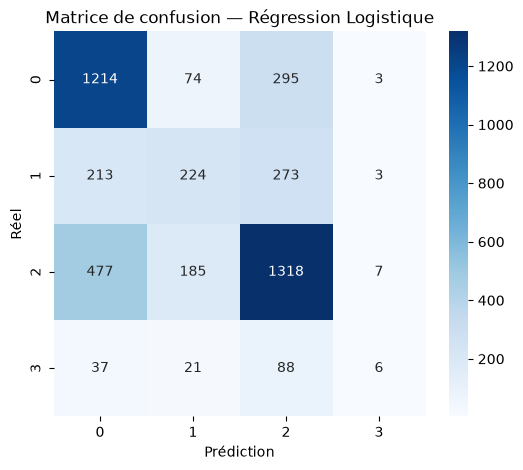

In [47]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, cohen_kappa_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ─── Pipeline SMOTE + Régression Logistique (baseline) ───
# Même logique que pour RF/XGBoost : SMOTE appliqué uniquement sur le train, dans le pipeline
pipeline_lr = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

# Entraînement sur les mêmes données que le modèle final (après fusion des grades 3 et 4)
pipeline_lr.fit(X_train_f, y_train_f)

# Prédictions
y_pred_lr = pipeline_lr.predict(X_test_f)

# ─── Évaluation ───
print("=== Régression Logistique (baseline) ===")
print(classification_report(y_test_f, y_pred_lr))

f1_macro_lr = f1_score(y_test_f, y_pred_lr, average='macro')
qwk_lr = cohen_kappa_score(y_test_f, y_pred_lr, weights='quadratic')

print(f"F1-macro : {f1_macro_lr:.3f}")
print(f"QWK      : {qwk_lr:.3f}")

# ─── Matrice de confusion ───
cm_lr = confusion_matrix(y_test_f, y_pred_lr)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title("Matrice de confusion — Régression Logistique")
plt.xlabel("Prédiction")
plt.ylabel("Réel")
plt.show()

In [23]:
from sklearn.model_selection import train_test_split

features = ['Age Année', 'Sexe', 'Milieu', 'Région', 'Circonstance',
            'Sous circonstance', 'type de produit1', ' Voie 1', 'Tranche_age']

X = df[features].copy()
y = df['Gradation finale'].copy()

variables_categorielles = ['Sexe', 'Milieu', 'Région', 'Circonstance',
                            'Sous circonstance', 'type de produit1',
                            ' Voie 1', 'Tranche_age']

X_encoded = pd.get_dummies(X, columns=variables_categorielles, drop_first=False)
print("Dimensions après encodage :", X_encoded.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Taille train :", X_train.shape)
print("Taille test :", X_test.shape)

Dimensions après encodage : (22188, 63)
Taille train : (17750, 63)
Taille test : (4438, 63)


In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, cohen_kappa_score

# Dictionnaire rempli au fur et à mesure — utilisé par le graphique de comparaison plus bas
resultats_modeles = {}

y_test_num = y_test.str.extract(r'(\d)').astype(int)[0]

def evaluer(y_pred, nom):
    print(f"=== {nom} ===")
    print(classification_report(y_test, y_pred, zero_division=0))
    y_pred_num = pd.Series(y_pred).str.extract(r'(\d)').astype(int)[0]
    qwk = cohen_kappa_score(y_test_num, y_pred_num, weights='quadratic')
    print(f"Quadratic Weighted Kappa : {round(qwk, 3)}\n")
    return qwk

In [25]:
model_rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
qwk_rf = evaluer(y_pred_rf, "Random Forest ")
resultats_modeles["RF"] = qwk_rf

=== Random Forest  ===
              precision    recall  f1-score   support

     Grade 0       0.61      0.69      0.65      1586
     Grade 1       0.49      0.33      0.40       713
     Grade 2       0.66      0.68      0.67      1987
     Grade 3       0.28      0.17      0.22       121
     Grade 4       0.15      0.06      0.09        31

    accuracy                           0.61      4438
   macro avg       0.44      0.39      0.40      4438
weighted avg       0.60      0.61      0.60      4438

Quadratic Weighted Kappa : 0.42



In [26]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_encoded)

model_xgb = XGBClassifier(n_estimators=200, random_state=42, eval_metric='mlogloss')
model_xgb.fit(X_train, y_train_encoded, sample_weight=sample_weights)
y_pred_xgb = le.inverse_transform(model_xgb.predict(X_test))
qwk_xgb = evaluer(y_pred_xgb, "XGBoost + sample_weight")
resultats_modeles["XGBoost\n(sample_weight)"] = qwk_xgb

=== XGBoost + sample_weight ===
              precision    recall  f1-score   support

     Grade 0       0.62      0.70      0.66      1586
     Grade 1       0.41      0.42      0.42       713
     Grade 2       0.74      0.55      0.63      1987
     Grade 3       0.10      0.29      0.14       121
     Grade 4       0.06      0.16      0.09        31

    accuracy                           0.57      4438
   macro avg       0.39      0.42      0.39      4438
weighted avg       0.62      0.57      0.59      4438

Quadratic Weighted Kappa : 0.393



In [27]:
from sklearn.model_selection import train_test_split

features = ['Age Année', 'Sexe', 'Milieu', 'Région', 'Circonstance',
            'Sous circonstance', 'type de produit1', ' Voie 1',
            'Tranche_age', 'Produit_Regroupe']

X = df[features].copy()
y = df['Gradation finale'].copy()

variables_categorielles = ['Sexe', 'Milieu', 'Région', 'Circonstance',
                            'Sous circonstance', 'type de produit1',
                            ' Voie 1', 'Tranche_age', 'Produit_Regroupe']

X_encoded = pd.get_dummies(X, columns=variables_categorielles, drop_first=False)
print("Dimensions après encodage :", X_encoded.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Taille train :", X_train.shape)
print("Taille test :", X_test.shape)

Dimensions après encodage : (22188, 156)
Taille train : (17750, 156)
Taille test : (4438, 156)


In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, cohen_kappa_score

# Dictionnaire rempli au fur et à mesure — utilisé par le graphique de comparaison plus bas
resultats_modeles = {}

y_test_num = y_test.str.extract(r'(\d)').astype(int)[0]

def evaluer(y_pred, nom):
    print(f"=== {nom} ===")
    print(classification_report(y_test, y_pred, zero_division=0))
    y_pred_num = pd.Series(y_pred).str.extract(r'(\d)').astype(int)[0]
    qwk = cohen_kappa_score(y_test_num, y_pred_num, weights='quadratic')
    print(f"Quadratic Weighted Kappa : {round(qwk, 3)}\n")
    return qwk

In [29]:
model_rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
qwk_rf = evaluer(y_pred_rf, "Random Forest — avec Produit_Regroupe")
resultats_modeles["RF\n(Produit_Regroupe)"] = qwk_rf

=== Random Forest — avec Produit_Regroupe ===
              precision    recall  f1-score   support

     Grade 0       0.63      0.71      0.67      1586
     Grade 1       0.58      0.37      0.45       713
     Grade 2       0.67      0.73      0.70      1987
     Grade 3       0.36      0.17      0.23       121
     Grade 4       0.20      0.10      0.13        31

    accuracy                           0.64      4438
   macro avg       0.49      0.42      0.44      4438
weighted avg       0.63      0.64      0.63      4438

Quadratic Weighted Kappa : 0.459



In [30]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_encoded)

model_xgb = XGBClassifier(n_estimators=200, random_state=42, eval_metric='mlogloss')
model_xgb.fit(X_train, y_train_encoded, sample_weight=sample_weights)
y_pred_xgb = le.inverse_transform(model_xgb.predict(X_test))
qwk_xgb = evaluer(y_pred_xgb, "XGBoost — Produit_Regroupe + sample_weight")
resultats_modeles["XGBoost\n(sample_weight)"] = qwk_xgb

=== XGBoost — Produit_Regroupe + sample_weight ===
              precision    recall  f1-score   support

     Grade 0       0.65      0.72      0.68      1586
     Grade 1       0.46      0.48      0.47       713
     Grade 2       0.78      0.57      0.66      1987
     Grade 3       0.12      0.40      0.18       121
     Grade 4       0.09      0.23      0.12        31

    accuracy                           0.60      4438
   macro avg       0.42      0.48      0.42      4438
weighted avg       0.66      0.60      0.62      4438

Quadratic Weighted Kappa : 0.427



In [31]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote_labels = smote.fit_resample(X_train, y_train)
y_train_smote_encoded = le.transform(y_train_smote_labels)

model_xgb_smote = XGBClassifier(n_estimators=200, random_state=42, eval_metric='mlogloss')
model_xgb_smote.fit(X_train_smote, y_train_smote_encoded)
y_pred_xgb_smote = le.inverse_transform(model_xgb_smote.predict(X_test))
qwk_smote = evaluer(y_pred_xgb_smote, "XGBoost — Produit_Regroupe + SMOTE")
resultats_modeles["XGBoost\n(SMOTE)"] = qwk_smote

=== XGBoost — Produit_Regroupe + SMOTE ===
              precision    recall  f1-score   support

     Grade 0       0.64      0.77      0.70      1586
     Grade 1       0.62      0.38      0.47       713
     Grade 2       0.70      0.72      0.71      1987
     Grade 3       0.37      0.15      0.21       121
     Grade 4       0.40      0.13      0.20        31

    accuracy                           0.66      4438
   macro avg       0.54      0.43      0.46      4438
weighted avg       0.65      0.66      0.65      4438

Quadratic Weighted Kappa : 0.498



In [32]:
print("Avant SMOTE :")
print(y_train.value_counts())

print("\nAprès SMOTE :")
print(pd.Series(y_train_smote_encoded).value_counts())

Avant SMOTE :
Gradation finale
Grade 2    7945
Grade 0    6343
Grade 1    2854
Grade 3     484
Grade 4     124
Name: count, dtype: int64

Après SMOTE :
2    7945
0    7945
1    7945
3    7945
4    7945
Name: count, dtype: int64


In [33]:
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import RandomizedSearchCV

pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', XGBClassifier(random_state=42, eval_metric='mlogloss'))
])

param_grid_pipeline = {
    'xgb__n_estimators': [100, 200, 300],
    'xgb__max_depth': [4, 6, 8, 10],
    'xgb__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'xgb__subsample': [0.7, 0.8, 1.0],
    'xgb__colsample_bytree': [0.7, 0.8, 1.0]
}

random_search_pipeline = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid_pipeline,
    n_iter=20,
    scoring='f1_macro',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search_pipeline.fit(X_train, y_train_encoded)

print("Meilleurs paramètres :", random_search_pipeline.best_params_)
print("Meilleur score F1-macro (validation croisée, correct) :", random_search_pipeline.best_score_)

meilleurs_params = random_search_pipeline.best_params_
best_model = random_search_pipeline.best_estimator_
y_pred_final = le.inverse_transform(best_model.predict(X_test))
qwk_final = evaluer(y_pred_final, "XGBoost optimisé (pipeline correct)")
resultats_modeles["XGBoost optimisé\n(pipeline correct)"] = qwk_final

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Meilleurs paramètres : {'xgb__subsample': 0.8, 'xgb__n_estimators': 100, 'xgb__max_depth': 10, 'xgb__learning_rate': 0.2, 'xgb__colsample_bytree': 1.0}
Meilleur score F1-macro (validation croisée, correct) : 0.43816651888105157
=== XGBoost optimisé (pipeline correct) ===
              precision    recall  f1-score   support

     Grade 0       0.64      0.77      0.70      1586
     Grade 1       0.64      0.38      0.48       713
     Grade 2       0.70      0.72      0.71      1987
     Grade 3       0.39      0.17      0.24       121
     Grade 4       0.38      0.16      0.23        31

    accuracy                           0.66      4438
   macro avg       0.55      0.44      0.47      4438
weighted avg       0.66      0.66      0.65      4438

Quadratic Weighted Kappa : 0.5



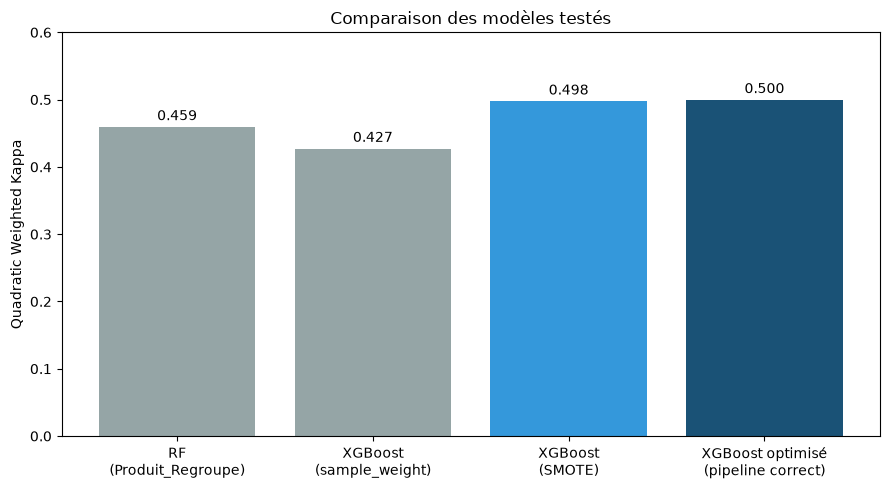

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(9, 5))
barres = plt.bar(resultats_modeles.keys(), resultats_modeles.values(),
                  color=['#95a5a6', '#95a5a6', '#3498db', '#1a5276'])
plt.ylabel("Quadratic Weighted Kappa")
plt.title("Comparaison des modèles testés")
plt.ylim(0, 0.6)
for bar in barres:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.3f}', ha='center')
plt.tight_layout()
plt.savefig(r"C:\Users\HP-PC\Downloads\comparaison_modeles.png", dpi=150)
plt.show()

In [36]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

pipeline_verif = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', XGBClassifier(
        n_estimators=meilleurs_params['xgb__n_estimators'],
        max_depth=meilleurs_params['xgb__max_depth'],
        learning_rate=meilleurs_params['xgb__learning_rate'],
        subsample=meilleurs_params['xgb__subsample'],
        colsample_bytree=meilleurs_params['xgb__colsample_bytree'],
        random_state=42,
        eval_metric='mlogloss'
    ))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores_cv = cross_val_score(
    pipeline_verif, X_train, y_train_encoded,
    cv=skf, scoring='f1_macro', n_jobs=-1
)

print("F1-macro sur 5 folds (train uniquement) :", scores_cv)
print(f"Moyenne : {scores_cv.mean():.3f}  Écart-type : {scores_cv.std():.3f}")

F1-macro sur 5 folds (train uniquement) : [0.44567316 0.45766254 0.43082663 0.45542457 0.45454079]
Moyenne : 0.449  Écart-type : 0.010


In [37]:
def fusionner_grades(grade):
    if grade in ['Grade 3', 'Grade 4']:
        return 'Sévère (3-4)'
    return grade

y_fusionne = y.apply(fusionner_grades)
print("Distribution après fusion :")
print(y_fusionne.value_counts())

le_fusionne = LabelEncoder()
y_fusionne_encoded = le_fusionne.fit_transform(y_fusionne)

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_encoded, y_fusionne,
    test_size=0.2, random_state=42, stratify=y_fusionne
)
y_train_f_encoded = le_fusionne.transform(y_train_f)
y_test_f_encoded = le_fusionne.transform(y_test_f)

# base_score=0.5 fixé explicitement — évite un bug de compatibilité SHAP/XGBoost multi-classe
pipeline_fusionne = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', XGBClassifier(
        n_estimators=meilleurs_params['xgb__n_estimators'],
        max_depth=meilleurs_params['xgb__max_depth'],
        learning_rate=meilleurs_params['xgb__learning_rate'],
        subsample=meilleurs_params['xgb__subsample'],
        colsample_bytree=meilleurs_params['xgb__colsample_bytree'],
        random_state=42,
        eval_metric='mlogloss',
        base_score=0.5
    ))
])

pipeline_fusionne.fit(X_train_f, y_train_f_encoded)

y_pred_f_encoded = pipeline_fusionne.predict(X_test_f)
y_pred_f = le_fusionne.inverse_transform(y_pred_f_encoded)

print("=== XGBoost final — 4 classes (Grade 3+4 fusionnés en 'Sévère') ===")
print(classification_report(y_test_f, y_pred_f, zero_division=0))

print("\n=== Focus classe Sévère (3-4) ===")
mask = y_test_f == 'Sévère (3-4)'
n_total = mask.sum()
n_correct = (y_pred_f[mask] == 'Sévère (3-4)').sum()
print(f"Sévère : {n_correct}/{n_total} correctement détectés ({100*n_correct/n_total:.1f}%)")

Distribution après fusion :
Gradation finale
Grade 2         9932
Grade 0         7929
Grade 1         3567
Sévère (3-4)     760
Name: count, dtype: int64
=== XGBoost final — 4 classes (Grade 3+4 fusionnés en 'Sévère') ===
              precision    recall  f1-score   support

     Grade 0       0.64      0.75      0.69      1586
     Grade 1       0.62      0.37      0.47       713
     Grade 2       0.69      0.72      0.70      1987
Sévère (3-4)       0.37      0.18      0.24       152

    accuracy                           0.66      4438
   macro avg       0.58      0.51      0.53      4438
weighted avg       0.65      0.66      0.64      4438


=== Focus classe Sévère (3-4) ===
Sévère : 27/152 correctement détectés (17.8%)


In [38]:
from sklearn.metrics import precision_recall_curve

idx_severe = list(le_fusionne.classes_).index('Sévère (3-4)')
y_proba_f = pipeline_fusionne.predict_proba(X_test_f)
proba_severe = y_proba_f[:, idx_severe]
y_test_binaire = (y_test_f == 'Sévère (3-4)').astype(int)

precision, recall, seuils = precision_recall_curve(y_test_binaire, proba_severe)

print("Seuil | Recall | Precision")
print("-" * 35)
for seuil_test in [0.5, 0.4, 0.3, 0.25, 0.2, 0.15, 0.1]:
    y_pred_seuil = (proba_severe >= seuil_test).astype(int)
    tp = ((y_pred_seuil == 1) & (y_test_binaire == 1)).sum()
    fp = ((y_pred_seuil == 1) & (y_test_binaire == 0)).sum()
    fn = ((y_pred_seuil == 0) & (y_test_binaire == 1)).sum()
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    print(f"{seuil_test:.2f} | {rec*100:5.1f}% | {prec:.3f}")

Seuil | Recall | Precision
-----------------------------------
0.50 |  14.5% | 0.449
0.40 |  15.8% | 0.369
0.30 |  20.4% | 0.313
0.25 |  20.4% | 0.252
0.20 |  23.0% | 0.206
0.15 |  25.0% | 0.167
0.10 |  34.2% | 0.152


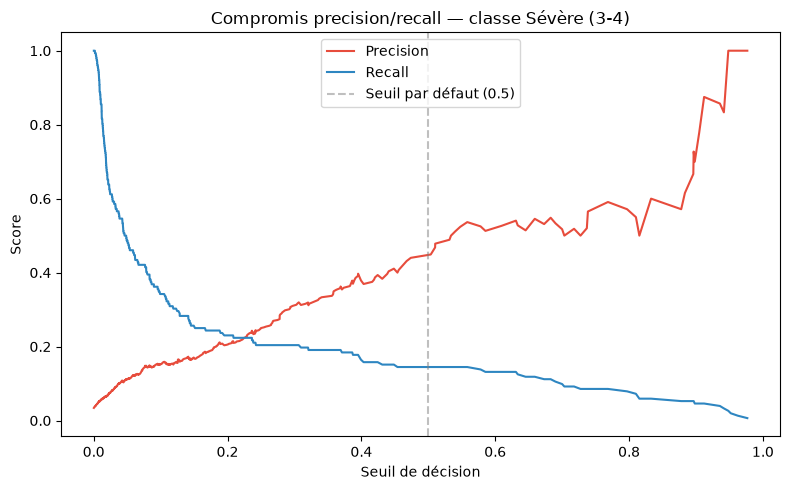

In [39]:
plt.figure(figsize=(8, 5))
plt.plot(seuils, precision[:-1], label='Precision', color='#e74c3c')
plt.plot(seuils, recall[:-1], label='Recall', color='#2e86c1')
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Seuil par défaut (0.5)')
plt.xlabel("Seuil de décision")
plt.ylabel("Score")
plt.title("Compromis precision/recall — classe Sévère (3-4)")
plt.legend()
plt.tight_layout()
plt.savefig(r"C:\Users\HP-PC\Downloads\compromis_seuil_severe.png", dpi=150)
plt.show()

In [40]:
import xgboost as xgb
import shap

xgb_model_final = pipeline_fusionne.named_steps['xgb']
booster = xgb_model_final.get_booster()

X_test_f_sample = X_test_f.sample(n=200, random_state=42).astype(float)
dmatrix = xgb.DMatrix(X_test_f_sample)

shap_raw = booster.predict(dmatrix, pred_contribs=True)
print("Forme :", shap_raw.shape)
print("Classes du modèle :", le_fusionne.classes_)

idx_severe = list(le_fusionne.classes_).index('Sévère (3-4)')
shap_values_severe = shap_raw[:, idx_severe, :-1]

Forme : (200, 4, 157)
Classes du modèle : ['Grade 0' 'Grade 1' 'Grade 2' 'Sévère (3-4)']


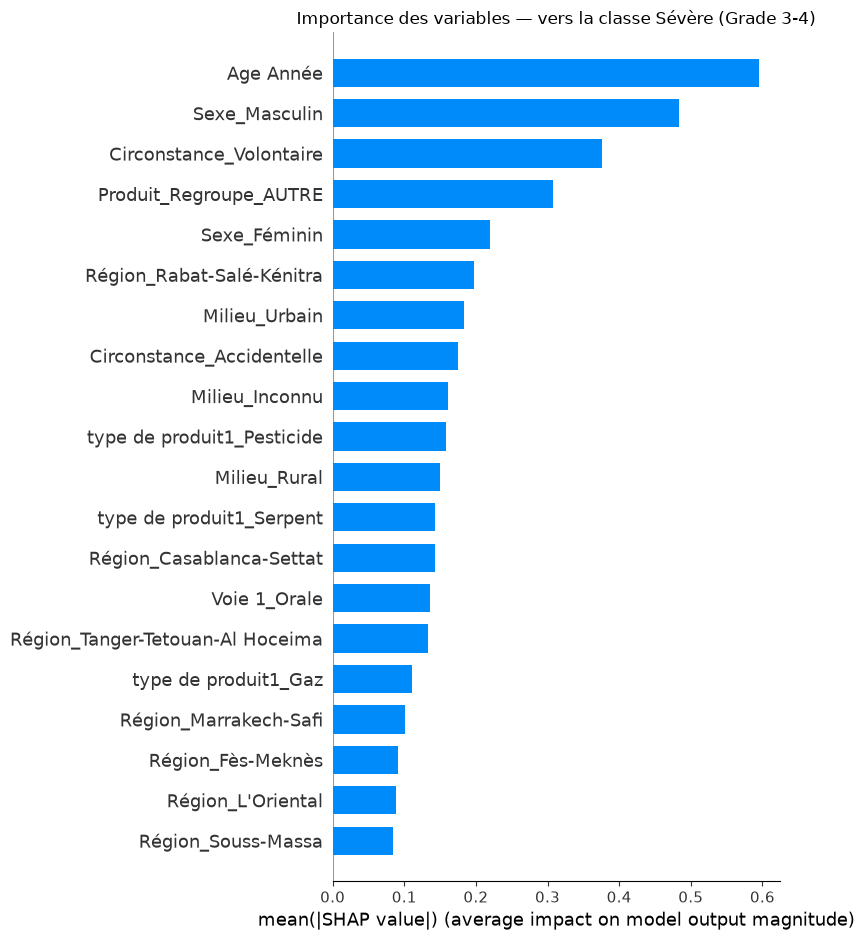

In [41]:
shap.summary_plot(
    shap_values_severe,
    X_test_f_sample,
    plot_type="bar",
    show=False
)
plt.title("Importance des variables — vers la classe Sévère (Grade 3-4)")
plt.tight_layout()
plt.savefig(r"C:\Users\HP-PC\Downloads\shap_bar_severe.png", dpi=150)
plt.show()

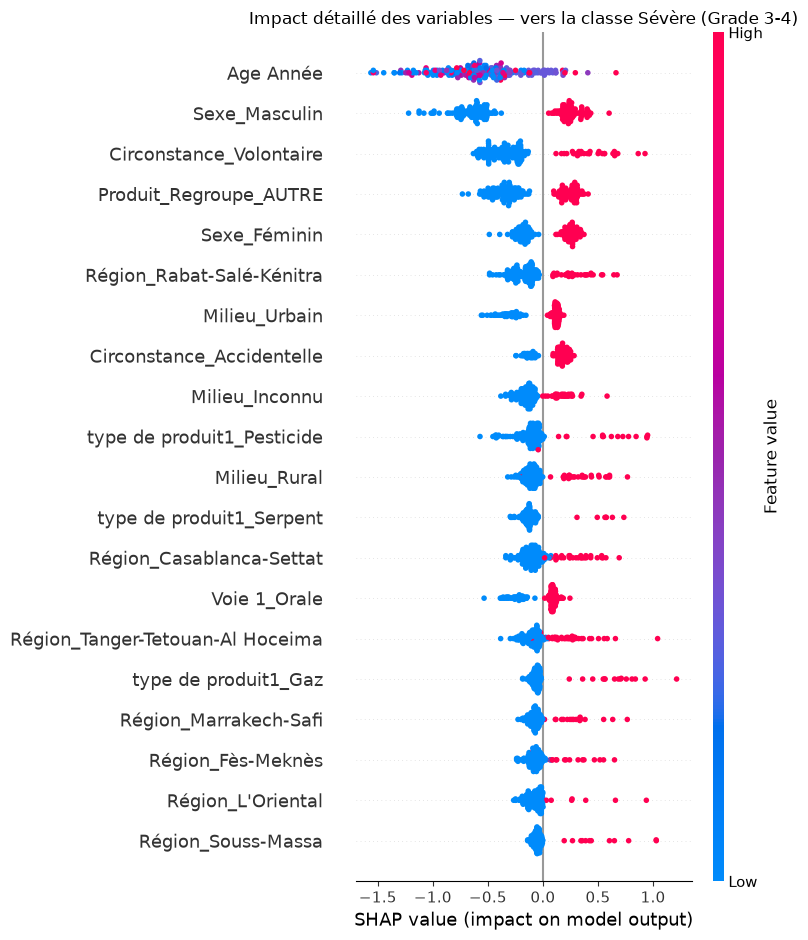

In [42]:
shap.summary_plot(
    shap_values_severe,
    X_test_f_sample,
    show=False
)
plt.title("Impact détaillé des variables — vers la classe Sévère (Grade 3-4)")
plt.tight_layout()
plt.savefig(r"C:\Users\HP-PC\Downloads\shap_detaille_severe.png", dpi=150)
plt.show()

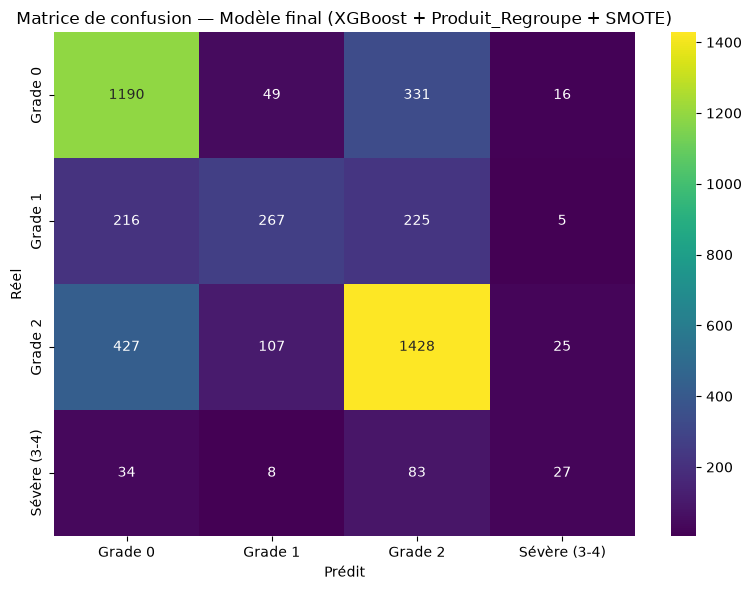

In [43]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_f, y_pred_f,
                       labels=['Grade 0', 'Grade 1', 'Grade 2', 'Sévère (3-4)'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
            xticklabels=['Grade 0', 'Grade 1', 'Grade 2', 'Sévère (3-4)'],
            yticklabels=['Grade 0', 'Grade 1', 'Grade 2', 'Sévère (3-4)'])
plt.title("Matrice de confusion — Modèle final (XGBoost + Produit_Regroupe + SMOTE)", fontsize=12)
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.tight_layout()
plt.savefig(r"C:\Users\HP-PC\Downloads\matrice_confusion_finale.png", dpi=150)
plt.show()

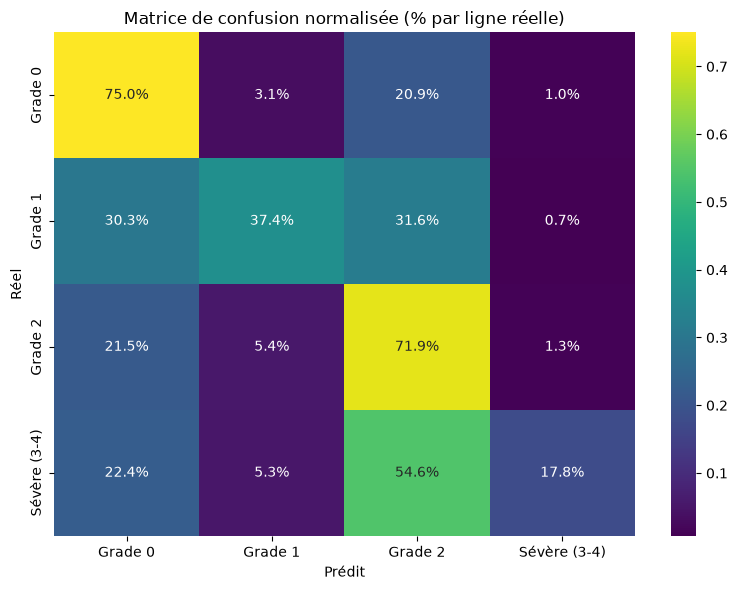

In [44]:
cm_normalisee = confusion_matrix(y_test_f, y_pred_f,
                                   labels=['Grade 0', 'Grade 1', 'Grade 2', 'Sévère (3-4)'],
                                   normalize='true')

plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalisee, annot=True, fmt='.1%', cmap='viridis',
            xticklabels=['Grade 0', 'Grade 1', 'Grade 2', 'Sévère (3-4)'],
            yticklabels=['Grade 0', 'Grade 1', 'Grade 2', 'Sévère (3-4)'])
plt.title("Matrice de confusion normalisée (% par ligne réelle)", fontsize=12)
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.tight_layout()
plt.savefig(r"C:\Users\HP-PC\Downloads\matrice_confusion_normalisee.png", dpi=150)
plt.show()

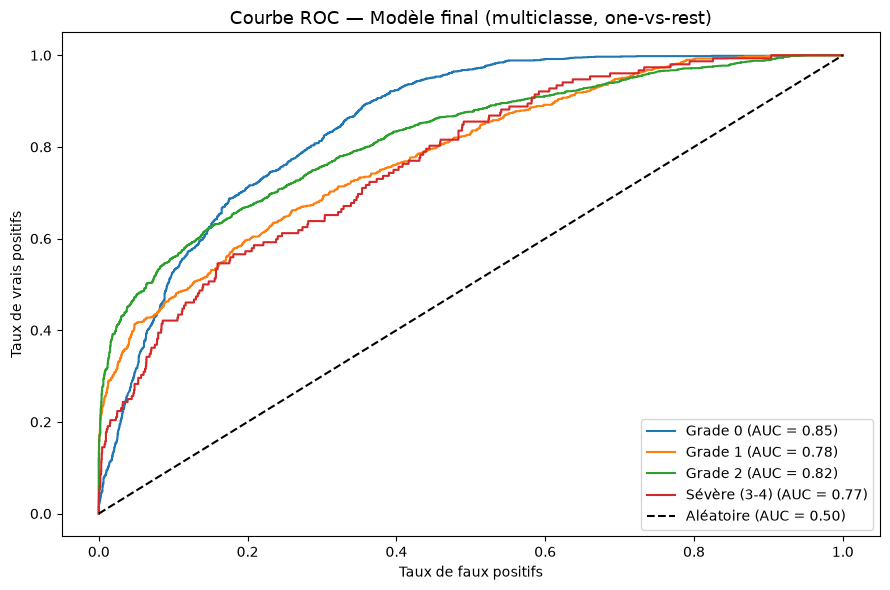

In [45]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

classes_finales = ['Grade 0', 'Grade 1', 'Grade 2', 'Sévère (3-4)']
y_test_bin = label_binarize(y_test_f, classes=classes_finales)
y_prob_final = pipeline_fusionne.predict_proba(X_test_f)

plt.figure(figsize=(9, 6))
for i, grade in enumerate(classes_finales):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_final[:, i])
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{grade} (AUC = {auc_score:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Aléatoire (AUC = 0.50)')
plt.title("Courbe ROC — Modèle final (multiclasse, one-vs-rest)", fontsize=13)
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(r"C:\Users\HP-PC\Downloads\courbe_roc_finale.png", dpi=150)
plt.show()

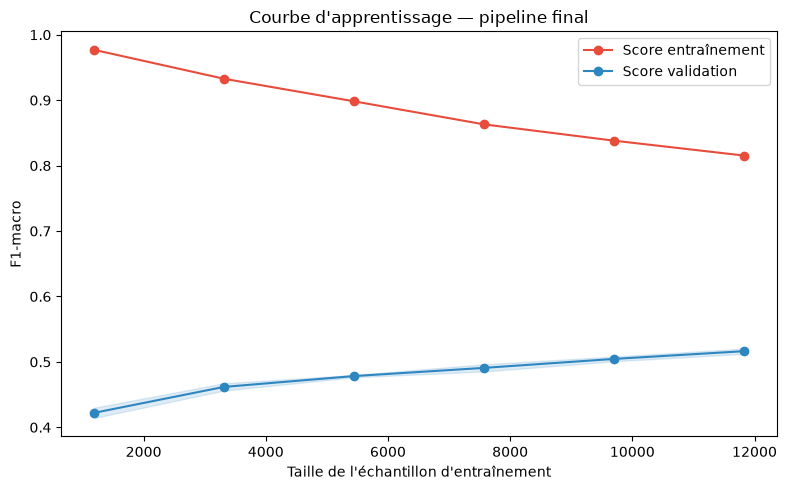

In [46]:
import numpy as np
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    pipeline_fusionne, X_train_f, y_train_f_encoded,
    cv=3, scoring='f1_macro', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 6),
    random_state=42
)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Score entraînement', color='#e74c3c')
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='Score validation', color='#2e86c1')
plt.fill_between(train_sizes, val_scores.mean(axis=1) - val_scores.std(axis=1),
                  val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.15, color='#2e86c1')
plt.xlabel("Taille de l'échantillon d'entraînement")
plt.ylabel("F1-macro")
plt.title("Courbe d'apprentissage — pipeline final")
plt.legend()
plt.tight_layout()
plt.savefig(r"C:\Users\HP-PC\Downloads\courbe_apprentissage.png", dpi=150)
plt.show()

In [48]:
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, f1_score, cohen_kappa_score

# ─── Pipeline SMOTE + Random Forest, optimisé de la même façon que XGBoost ───
pipeline_rf = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42, n_jobs=-1))
])

param_grid_rf = {
    'rf__n_estimators': [100, 200, 300, 500],
    'rf__max_depth': [None, 10, 15, 20, 30],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
    'rf__max_features': ['sqrt', 'log2']
}

random_search_rf = RandomizedSearchCV(
    estimator=pipeline_rf,
    param_distributions=param_grid_rf,
    n_iter=20,
    scoring='f1_macro',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

# Entraînement sur les mêmes données que le modèle XGBoost final (après fusion des grades)
random_search_rf.fit(X_train_f, y_train_f_encoded)

meilleurs_params_rf = random_search_rf.best_params_
print("Meilleurs paramètres RF :", meilleurs_params_rf)
print("Meilleur score F1-macro (validation croisée) :", random_search_rf.best_score_)

# ─── Évaluation sur le jeu de test, comme pour XGBoost ───
pipeline_rf_final = random_search_rf.best_estimator_
y_pred_rf_encoded = pipeline_rf_final.predict(X_test_f)
y_pred_rf_final = le_fusionne.inverse_transform(y_pred_rf_encoded)

print("\n=== Random Forest optimisé — mêmes données que XGBoost final ===")
print(classification_report(y_test_f, y_pred_rf_final, zero_division=0))

f1_macro_rf = f1_score(y_test_f, y_pred_rf_final, average='macro')
qwk_rf_final = cohen_kappa_score(y_test_f_encoded, y_pred_rf_encoded, weights='quadratic')

mask_rf = y_test_f == 'Sévère (3-4)'
n_correct_rf = (y_pred_rf_final[mask_rf] == 'Sévère (3-4)').sum()
n_total_rf = mask_rf.sum()

print(f"F1-macro : {f1_macro_rf:.3f}")
print(f"QWK      : {qwk_rf_final:.3f}")
print(f"Recall Sévère : {n_correct_rf}/{n_total_rf} ({100*n_correct_rf/n_total_rf:.1f}%)")

# ─── Comparatif direct avec XGBoost ───
print("\n=== COMPARATIF FINAL ===")
print(f"{'Modèle':<25}{'F1-macro':>10}{'QWK':>10}{'Recall Sévère':>16}")
print(f"{'XGBoost (optimisé)':<25}{0.530:>10}{'?':>10}{'17.8%':>16}")
print(f"{'Random Forest (optimisé)':<25}{f1_macro_rf:>10.3f}{qwk_rf_final:>10.3f}{f'{100*n_correct_rf/n_total_rf:.1f}%':>16}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Meilleurs paramètres RF : {'rf__n_estimators': 500, 'rf__min_samples_split': 2, 'rf__min_samples_leaf': 2, 'rf__max_features': 'sqrt', 'rf__max_depth': None}
Meilleur score F1-macro (validation croisée) : 0.5169751024780823

=== Random Forest optimisé — mêmes données que XGBoost final ===
              precision    recall  f1-score   support

     Grade 0       0.63      0.76      0.69      1586
     Grade 1       0.60      0.40      0.48       713
     Grade 2       0.72      0.69      0.70      1987
Sévère (3-4)       0.26      0.27      0.26       152

    accuracy                           0.65      4438
   macro avg       0.55      0.53      0.53      4438
weighted avg       0.65      0.65      0.65      4438

F1-macro : 0.534
QWK      : 0.478
Recall Sévère : 41/152 (27.0%)

=== COMPARATIF FINAL ===
Modèle                     F1-macro       QWK   Recall Sévère
XGBoost (optimisé)             0.53         ?           17.8%

In [49]:
qwk_xgb_final = cohen_kappa_score(y_test_f_encoded, le_fusionne.transform(y_pred_f), weights='quadratic')
print(f"QWK XGBoost final : {qwk_xgb_final:.3f}")

QWK XGBoost final : 0.489


In [50]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict

# ─── Vérification de la stabilité de Random Forest optimisé (5 folds, sur le train) ───
pipeline_rf_verif = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(
        n_estimators=meilleurs_params_rf['rf__n_estimators'],
        max_depth=meilleurs_params_rf['rf__max_depth'],
        min_samples_split=meilleurs_params_rf['rf__min_samples_split'],
        min_samples_leaf=meilleurs_params_rf['rf__min_samples_leaf'],
        max_features=meilleurs_params_rf['rf__max_features'],
        random_state=42,
        n_jobs=-1
    ))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores_cv_rf = cross_val_score(
    pipeline_rf_verif, X_train_f, y_train_f_encoded,
    cv=skf, scoring='f1_macro', n_jobs=-1
)

print("F1-macro sur 5 folds (Random Forest, train uniquement) :", scores_cv_rf)
print(f"Moyenne : {scores_cv_rf.mean():.3f}  Écart-type : {scores_cv_rf.std():.3f}")

# ─── Vérifier aussi la stabilité du recall sur la classe Sévère à travers les folds ───
idx_severe_f = list(le_fusionne.classes_).index('Sévère (3-4)')

y_pred_cv_rf = cross_val_predict(
    pipeline_rf_verif, X_train_f, y_train_f_encoded,
    cv=skf, n_jobs=-1
)

from sklearn.metrics import recall_score
recall_severe_folds = []
for train_idx, test_idx in skf.split(X_train_f, y_train_f_encoded):
    y_true_fold = y_train_f_encoded[test_idx] if hasattr(y_train_f_encoded, '__getitem__') else y_train_f_encoded.iloc[test_idx]
    y_pred_fold = y_pred_cv_rf[test_idx]
    mask = y_true_fold == idx_severe_f
    if mask.sum() > 0:
        recall_severe_folds.append((y_pred_fold[mask] == idx_severe_f).sum() / mask.sum())

import numpy as np
print(f"\nRecall Sévère par fold : {[round(r, 3) for r in recall_severe_folds]}")
print(f"Moyenne : {np.mean(recall_severe_folds):.3f}  Écart-type : {np.std(recall_severe_folds):.3f}")

F1-macro sur 5 folds (Random Forest, train uniquement) : [0.51229482 0.51410138 0.53463105 0.49718398 0.5167695 ]
Moyenne : 0.515  Écart-type : 0.012

Recall Sévère par fold : [np.float64(0.19), np.float64(0.198), np.float64(0.254), np.float64(0.197), np.float64(0.172)]
Moyenne : 0.202  Écart-type : 0.028


In [51]:
# ─── Même vérification de stabilité, mais pour XGBoost, sur le MÊME problème à 4 classes fusionnées ───
pipeline_xgb_verif_f = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', XGBClassifier(
        n_estimators=meilleurs_params['xgb__n_estimators'],
        max_depth=meilleurs_params['xgb__max_depth'],
        learning_rate=meilleurs_params['xgb__learning_rate'],
        subsample=meilleurs_params['xgb__subsample'],
        colsample_bytree=meilleurs_params['xgb__colsample_bytree'],
        random_state=42,
        eval_metric='mlogloss'
    ))
])

scores_cv_xgb_f = cross_val_score(
    pipeline_xgb_verif_f, X_train_f, y_train_f_encoded,
    cv=skf, scoring='f1_macro', n_jobs=-1
)
print("F1-macro sur 5 folds (XGBoost, 4 classes fusionnées) :", scores_cv_xgb_f)
print(f"Moyenne : {scores_cv_xgb_f.mean():.3f}  Écart-type : {scores_cv_xgb_f.std():.3f}")

y_pred_cv_xgb_f = cross_val_predict(
    pipeline_xgb_verif_f, X_train_f, y_train_f_encoded,
    cv=skf, n_jobs=-1
)

recall_severe_folds_xgb = []
for train_idx, test_idx in skf.split(X_train_f, y_train_f_encoded):
    y_true_fold = y_train_f_encoded[test_idx] if hasattr(y_train_f_encoded, '__getitem__') else y_train_f_encoded.iloc[test_idx]
    y_pred_fold = y_pred_cv_xgb_f[test_idx]
    mask = y_true_fold == idx_severe_f
    if mask.sum() > 0:
        recall_severe_folds_xgb.append((y_pred_fold[mask] == idx_severe_f).sum() / mask.sum())

print(f"\nRecall Sévère par fold (XGBoost) : {[round(r, 3) for r in recall_severe_folds_xgb]}")
print(f"Moyenne : {np.mean(recall_severe_folds_xgb):.3f}  Écart-type : {np.std(recall_severe_folds_xgb):.3f}")

F1-macro sur 5 folds (XGBoost, 4 classes fusionnées) : [0.51061256 0.51622833 0.52832456 0.50918271 0.52373617]
Moyenne : 0.518  Écart-type : 0.007

Recall Sévère par fold (XGBoost) : [np.float64(0.124), np.float64(0.149), np.float64(0.164), np.float64(0.148), np.float64(0.164)]
Moyenne : 0.150  Écart-type : 0.015


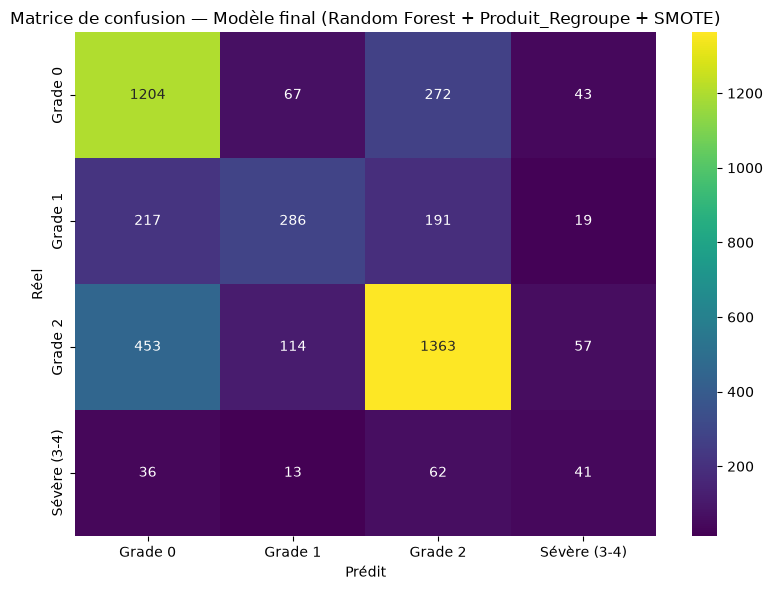

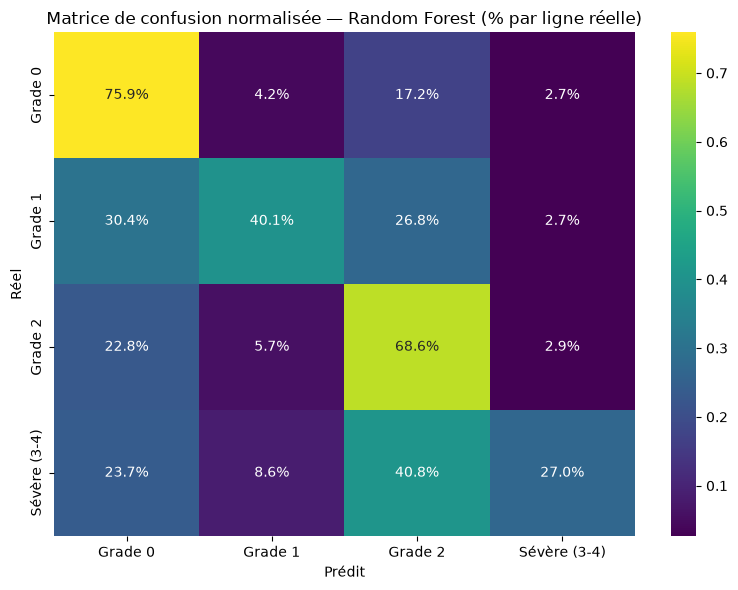

In [52]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

classes_finales = ['Grade 0', 'Grade 1', 'Grade 2', 'Sévère (3-4)']

cm_rf = confusion_matrix(y_test_f, y_pred_rf_final, labels=classes_finales)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='viridis',
            xticklabels=classes_finales, yticklabels=classes_finales)
plt.title("Matrice de confusion — Modèle final (Random Forest + Produit_Regroupe + SMOTE)", fontsize=12)
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.tight_layout()
plt.savefig(r"C:\Users\HP-PC\Downloads\matrice_confusion_rf_finale.png", dpi=150)
plt.show()

cm_rf_normalisee = confusion_matrix(y_test_f, y_pred_rf_final, labels=classes_finales, normalize='true')
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf_normalisee, annot=True, fmt='.1%', cmap='viridis',
            xticklabels=classes_finales, yticklabels=classes_finales)
plt.title("Matrice de confusion normalisée — Random Forest (% par ligne réelle)", fontsize=12)
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.tight_layout()
plt.savefig(r"C:\Users\HP-PC\Downloads\matrice_confusion_rf_normalisee.png", dpi=150)
plt.show()

Seuil | Recall | Precision
-----------------------------------
0.50 |  11.8% | 0.367
0.40 |  19.1% | 0.282
0.30 |  31.6% | 0.223
0.25 |  38.2% | 0.188
0.20 |  43.4% | 0.149
0.15 |  51.3% | 0.119
0.10 |  69.1% | 0.088


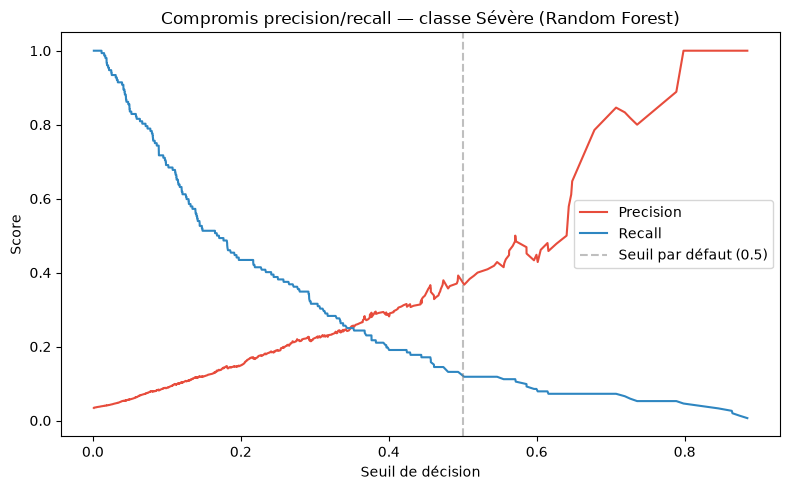

In [53]:
from sklearn.metrics import precision_recall_curve

idx_severe_rf = list(le_fusionne.classes_).index('Sévère (3-4)')
y_proba_rf = pipeline_rf_final.predict_proba(X_test_f)
proba_severe_rf = y_proba_rf[:, idx_severe_rf]
y_test_binaire_rf = (y_test_f == 'Sévère (3-4)').astype(int)

precision_rf, recall_rf, seuils_rf = precision_recall_curve(y_test_binaire_rf, proba_severe_rf)

print("Seuil | Recall | Precision")
print("-" * 35)
for seuil_test in [0.5, 0.4, 0.3, 0.25, 0.2, 0.15, 0.1]:
    y_pred_seuil = (proba_severe_rf >= seuil_test).astype(int)
    tp = ((y_pred_seuil == 1) & (y_test_binaire_rf == 1)).sum()
    fp = ((y_pred_seuil == 1) & (y_test_binaire_rf == 0)).sum()
    fn = ((y_pred_seuil == 0) & (y_test_binaire_rf == 1)).sum()
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    print(f"{seuil_test:.2f} | {rec*100:5.1f}% | {prec:.3f}")

plt.figure(figsize=(8, 5))
plt.plot(seuils_rf, precision_rf[:-1], label='Precision', color='#e74c3c')
plt.plot(seuils_rf, recall_rf[:-1], label='Recall', color='#2e86c1')
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Seuil par défaut (0.5)')
plt.xlabel("Seuil de décision")
plt.ylabel("Score")
plt.title("Compromis precision/recall — classe Sévère (Random Forest)")
plt.legend()
plt.tight_layout()
plt.savefig(r"C:\Users\HP-PC\Downloads\compromis_seuil_severe_rf.png", dpi=150)
plt.show()

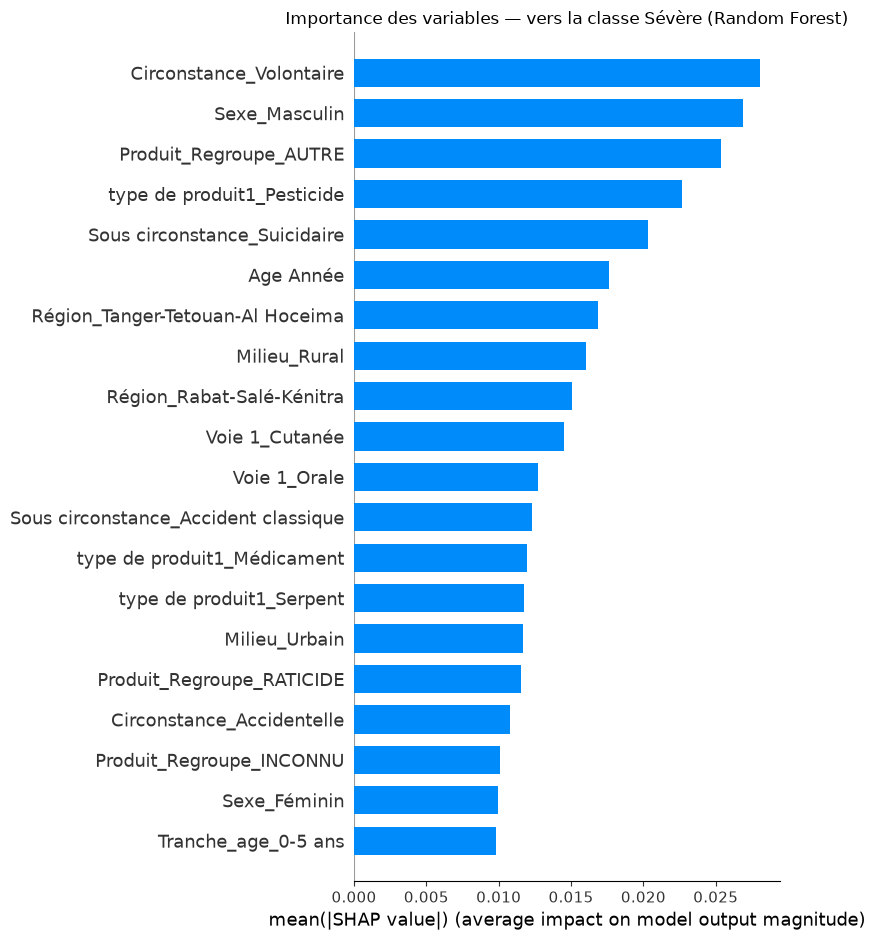

In [56]:
import shap

rf_model_final = pipeline_rf_final.named_steps['rf']

# Échantillon plus petit pour que ça tourne en quelques secondes/minutes au lieu de rester bloqué
X_test_f_sample_rf = X_test_f.sample(n=50, random_state=42)

explainer_rf = shap.TreeExplainer(rf_model_final)
shap_values_rf = explainer_rf.shap_values(X_test_f_sample_rf, check_additivity=False)

idx_severe_shap = list(le_fusionne.classes_).index('Sévère (3-4)')
shap_values_severe_rf = shap_values_rf[idx_severe_shap] if isinstance(shap_values_rf, list) else shap_values_rf[:, :, idx_severe_shap]

shap.summary_plot(shap_values_severe_rf, X_test_f_sample_rf, plot_type="bar", show=False)
plt.title("Importance des variables — vers la classe Sévère (Random Forest)")
plt.tight_layout()
plt.savefig(r"C:\Users\HP-PC\Downloads\shap_bar_severe_rf.png", dpi=150)
plt.show()

In [55]:
from sklearn.metrics import fbeta_score

print("Seuil | Recall | Precision | F2-score")
print("-" * 45)
meilleur_f2 = 0
meilleur_seuil = 0
for seuil_test in [0.5, 0.4, 0.35, 0.3, 0.25, 0.2, 0.15, 0.1]:
    y_pred_seuil = (proba_severe_rf >= seuil_test).astype(int)
    f2 = fbeta_score(y_test_binaire_rf, y_pred_seuil, beta=2)
    tp = ((y_pred_seuil == 1) & (y_test_binaire_rf == 1)).sum()
    fp = ((y_pred_seuil == 1) & (y_test_binaire_rf == 0)).sum()
    fn = ((y_pred_seuil == 0) & (y_test_binaire_rf == 1)).sum()
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    print(f"{seuil_test:.2f} | {rec*100:5.1f}% | {prec:.3f} | {f2:.3f}")
    if f2 > meilleur_f2:
        meilleur_f2, meilleur_seuil = f2, seuil_test

print(f"\nMeilleur seuil selon F2-score : {meilleur_seuil} (F2 = {meilleur_f2:.3f})")

Seuil | Recall | Precision | F2-score
---------------------------------------------
0.50 |  11.8% | 0.367 | 0.137
0.40 |  19.1% | 0.282 | 0.204
0.35 |  25.0% | 0.257 | 0.251
0.30 |  31.6% | 0.223 | 0.292
0.25 |  38.2% | 0.188 | 0.317
0.20 |  43.4% | 0.149 | 0.314
0.15 |  51.3% | 0.119 | 0.309
0.10 |  69.1% | 0.088 | 0.292

Meilleur seuil selon F2-score : 0.25 (F2 = 0.317)
